# Grounding DINO Implementaion

This notebook is organized into grouped phases for the Grounding DINO grasp-point prediction workflow. We begin with setup and data inspection, move into validation-based prompt selection, and then finish with test evaluation, exports, and diagnostics.

**Metric version:** True pixel error with CLIP-style diagonal-normalized pixel error.


## Phase 1: Setup and Data Preparation

In this phase, we install dependencies, mount storage when needed, import libraries, check the compute device, configure project paths, and inspect the dataset. The goal is to make sure the environment and annotations are ready before running any model experiments.

In [ ]:
# Install the notebook dependencies needed for Grounding DINO inference and visualization.
!pip -q install "transformers>=4.51,<4.58" "accelerate>=0.30,<1.0" "pillow>=10,<12" matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.7 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive in Colab so the notebook can access the project files.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the libraries used for data loading, visualization, and model inference.
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor

In [ ]:
# Check the PyTorch and CUDA setup before loading the model.
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.10.0+cu128
CUDA available: True
Device: cuda


### Step 1: Dataset Paths and Project Configuration

This section locates the project root, connects the notebook to the dataset folders, and creates an output directory for saved results.

In [ ]:
# Configure the project, dataset, and output paths used throughout the notebook.
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/content/drive/MyDrive/Grasp Point Prediction"),
    Path("/content/drive/MyDrive/eng521/Grasp Point Prediction"),
]

# Try a small list of likely roots so the same notebook works in Colab and locally.
PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "data" / "pixmo_subset_v3").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root. Set PROJECT_ROOT manually in this cell."
    )

DATASET_NAME = "pixmo_subset_v3"
DATA_ROOT = PROJECT_ROOT / "data" / DATASET_NAME
# Handle nested layouts like data/pixmo_subset_v3/pixmo_subset_v3/.
if DATA_ROOT.exists() and not (DATA_ROOT / "metadata.json").exists():
    for child in sorted(DATA_ROOT.iterdir()):
        if child.is_dir() and (child / "metadata.json").exists():
            DATA_ROOT = child
            break

SPLITS_DIR = DATA_ROOT / "splits"
IMAGES_DIR = DATA_ROOT / "images"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "grounding_dino_true_pixel_error"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_NAME:", DATASET_NAME)
print("DATA_ROOT:", DATA_ROOT)
print("SPLITS_DIR exists:", SPLITS_DIR.exists())
print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Grasp Point Prediction
DATASET_NAME: pixmo_subset_v3
DATA_ROOT: /content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3
SPLITS_DIR exists: True
IMAGES_DIR exists: True
OUTPUT_DIR: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error


### Step 2: Dataset Statistics and Metadata Inspection

Here we summarize the dataset, check split sizes and labels, and preview the metadata format so we can validate that the input annotations are correct.

In [ ]:
# Summarize the dataset size, split counts, and label distribution.
import json
from collections import Counter

if 'DATA_ROOT' not in globals():
    raise RuntimeError('DATA_ROOT is not defined Ã¢â‚¬â€ run the Project Paths cell first')

meta_path = DATA_ROOT / 'metadata.json'
if not meta_path.exists():
    raise FileNotFoundError(f'Metadata not found: {meta_path}')

with open(meta_path, 'r', encoding='utf-8') as f:
    full_meta = json.load(f)

total_samples = len(full_meta)
unique_labels = sorted({r.get('label') for r in full_meta})
label_counts = Counter(r.get('label') for r in full_meta)
images_count = len(list((DATA_ROOT / 'images').glob('*.*')))
pointing_overall = sum(1 for r in full_meta if r.get('collection_method') == 'pointing')

split_counts = {}
for split_name in ['train', 'val', 'test']:
    p = SPLITS_DIR / f'{split_name}.json'
    if p.exists():
        with open(p, 'r', encoding='utf-8') as sf:
            d = json.load(sf)
        split_counts[split_name] = len(d)
    else:
        split_counts[split_name] = None

print('Dataset root:', DATA_ROOT)
print('Total metadata entries:', total_samples)
print('Images in images/ folder:', images_count)
print('Unique labels:', len(unique_labels))
print('Pointing samples overall:', pointing_overall)
print('Split sizes:', split_counts)
print('Top label counts (10):', label_counts.most_common(10))


Dataset root: /content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3
Total metadata entries: 914
Images in images/ folder: 914
Unique labels: 48
Pointing samples overall: 914
Split sizes: {'train': 548, 'val': 183, 'test': 183}
Top label counts (10): [('backpack', 20), ('bag', 20), ('calculator', 20), ('charger', 20), ('headphones', 20), ('jar', 20), ('kettle', 20), ('keyboard', 20), ('laptop', 20), ('mouse', 20)]


### Step 3: Metadata Preview

This quick preview shows the structure of individual records, including labels, image paths, and pointing annotations used later in evaluation.

In [ ]:
# Preview the dataset metadata structure to confirm the expected fields are present.
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Expected dataset folder not found: {DATA_ROOT}")

metadata_path = DATA_ROOT / "metadata.json"
print("Using dataset folder:", DATA_ROOT)
print("Metadata file exists:", metadata_path.exists())

if metadata_path.exists():
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print("Metadata preview:")
    print(json.dumps(metadata, indent=2)[:1000])

Using dataset folder: /content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3
Metadata file exists: True
Metadata preview:
[
  {
    "id": 0,
    "label": "backpack",
    "collection_method": "pointing",
    "count": null,
    "points": [
      {
        "x": 74.1666603693891,
        "y": 56.026233491443456
      }
    ],
    "image_path": "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3/images/backpack_1.jpg",
    "image_url": "http://www.andes.org.uk/peak-info-6000/famatina-summit.jpg"
  },
  {
    "id": 1,
    "label": "backpack",
    "collection_method": "pointing",
    "count": null,
    "points": [
      {
        "x": 60.88331997284503,
        "y": 50.31865618565404
      }
    ],
    "image_path": "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3/images/backpack_2.jpg",
    "image_url": "https://i.dailymail.co.uk/1s/2020/08/16/13/31998746-8631821-With_his_Proud_Boy_tattoo_proudly_on_display_an_alt_right_counte-a-6_

## Phase 2: Validation Data Preparation

In this phase, we load the validation split, inspect the available categories, isolate the pointing samples, and visualize one example. This prepares the validation data that will be used for prompt selection.

In [ ]:
# Load the validation split that will be used for prompt selection.
SPLIT_NAME = "val"  # validation split for prompt selection
SPLIT_PATH = SPLITS_DIR / f"{SPLIT_NAME}.json"

with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    split_data = json.load(f)

print("Loaded split:", SPLIT_NAME)
print("Number of rows:", len(split_data))
print("Available keys:", sorted(split_data[0].keys()))
print("Example row:\n")
print(json.dumps(split_data[0], indent=2)[:2000])

Loaded split: val
Number of rows: 183
Available keys: ['collection_method', 'count', 'id', 'image_path', 'image_url', 'label', 'points']
Example row:

{
  "id": 403,
  "label": "apple",
  "collection_method": "pointing",
  "count": null,
  "points": [
    {
      "x": 54.82142857142858,
      "y": 43.214285714285715
    }
  ],
  "image_path": "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3/images/apple_2.jpg",
  "image_url": "https://img.freepik.com/premium-vector/food-basket-flat-vector-illustration-food-basket-hand-drawing-isolated-vector-illustration_501705-688.jpg"
}


In [ ]:
# List the unique object labels available in the selected split.
labels_in_split = sorted({row["label"] for row in split_data})
print("Unique labels in split:", len(labels_in_split))
print(labels_in_split)

Unique labels in split: 48
['apple', 'backpack', 'bag', 'basket', 'book', 'bottle', 'bowl', 'calculator', 'charger', 'cup', 'earbuds', 'egg', 'fork', 'glove', 'hairbrush', 'headphones', 'highlighter', 'jar', 'kettle', 'keyboard', 'keys', 'knife', 'laptop', 'marker', 'mouse', 'mug', 'notebook', 'onion', 'pan', 'pen', 'phone', 'plate', 'pot', 'remote', 'scissor', 'shoe', 'sock', 'spatula', 'spoon', 'stapler', 't-shirt', 'tape', 'tomato', 'toothbrush', 'tray', 'umbrella', 'wallet', 'watch']


In [ ]:
# Filter the split to the pointing samples used for grasp-point evaluation.
pointing_samples = [
    row for row in split_data
    if row.get("collection_method") == "pointing"
]

print("Pointing samples:", len(pointing_samples))
print("First pointing sample id:", pointing_samples[0]["id"] if pointing_samples else None)

Pointing samples: 183
First pointing sample id: 403


### Step 1: Validation Example Inspection

This section displays a sample validation image and its ground-truth point to sanity-check the annotations before inference.

Label: backpack
Filename: backpack_10.jpg
Image path: /content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3/images/backpack_10.jpg
Point count: 1


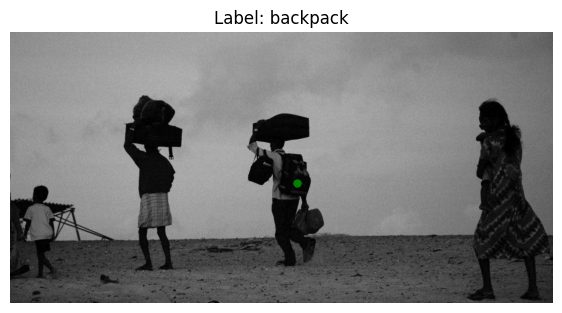

In [ ]:
# Visualize one validation sample and its annotated grasp point.
sample = pointing_samples[5]
label = sample["label"]
points = sample["points"]
filename = os.path.basename(sample["image_path"])
image_path = IMAGES_DIR / filename

print("Label:", label)
print("Filename:", filename)
print("Image path:", image_path)
print("Point count:", len(points))

image = Image.open(image_path).convert("RGB")
# Convert percentage-based annotations into pixel coordinates for plotting.
img_w, img_h = image.size

plt.figure(figsize=(7, 7))
plt.imshow(image)

for point in points:
    px = (point["x"] / 100.0) * img_w
    py = (point["y"] / 100.0) * img_h
    plt.plot(px, py, "go", markersize=5)

plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

## Phase 3: Model Loading and Single-Image Check

Here we load the Grounding DINO processor and model, move them to the selected device, and run a first inference on one example image. This gives us a quick qualitative check before large-scale evaluation.

In [ ]:
# Load the Grounding DINO processor and model onto the selected device.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

print("Loaded model:", MODEL_ID)
print("Using device:", DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loaded model: IDEA-Research/grounding-dino-tiny
Using device: cuda


### Step 1: Single-Image Inference

This section runs Grounding DINO on one image with a prompt, converts detections into boxes, and compares the prediction to the ground-truth point.

In [ ]:
# Run Grounding DINO on one sample to inspect the raw detections.
prompt = f"point to the {label}."
gt_x = float(points[0]["x"])
gt_y = float(points[0]["y"])
gt_x_px = (gt_x / 100.0) * img_w
gt_y_px = (gt_y / 100.0) * img_h

inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

# Run one forward pass to verify the prompt produces sensible detections.
with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]], device=DEVICE)
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=target_sizes,
    threshold=0.30,
    text_threshold=0.25,
)

result = results[0]
boxes = result["boxes"]
scores = result["scores"]
labels_out = result["labels"]

print("Prompt:", prompt)
print("Detections:", len(boxes))

Prompt: point to the backpack.
Detections: 1


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Best box: [537.21265 241.04242 611.22986 335.467  ]
Best score: 0.4509434103965759
Matched text: backpack
Predicted point (0-100): (np.float32(52.20193), np.float32(52.409946))
Ground-truth point (0-100): (52.8387831462502, 55.806084268748975)
Error: 3.4553332970445196


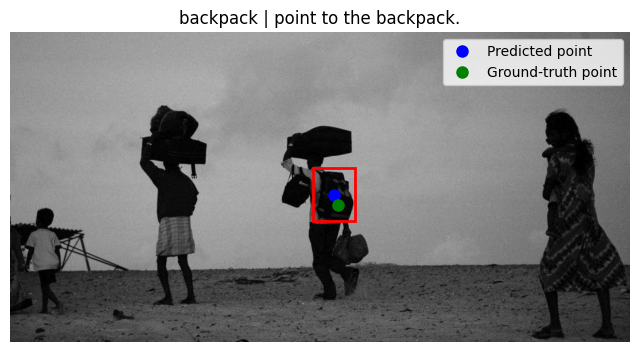

In [ ]:
# Visualize the best detection against the ground-truth grasp point.
if len(boxes) == 0:
    print("No detections found.")
else:
    best_idx = scores.argmax().item()
    best_box = boxes[best_idx].detach().cpu().numpy()
    best_score = scores[best_idx].item()
    best_text = labels_out[best_idx]

    x1, y1, x2, y2 = best_box
    center_x = (x1 + x2) / 2.0
    center_y = (y1 + y2) / 2.0
    pred_x_norm = (center_x / img_w) * 100.0
    pred_y_norm = (center_y / img_h) * 100.0
    error = math.sqrt((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2)

    print("Best box:", best_box)
    print("Best score:", best_score)
    print("Matched text:", best_text)
    print("Predicted point (0-100):", (pred_x_norm, pred_y_norm))
    print("Ground-truth point (0-100):", (gt_x, gt_y))
    print("Error:", error)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.plot(center_x, center_y, "bo", markersize=8, label="Predicted point")
    ax.plot(gt_x_px, gt_y_px, "go", markersize=8, label="Ground-truth point")
    ax.legend()
    ax.set_title(f"{label} | {prompt}")
    ax.axis("off")
    plt.show()

## Phase 4: Validation Prompt Evaluation

This is the main validation phase. We define helper functions, set up prompt templates and success criteria, run prompt evaluation on the validation split, compare results across categories, and save the validation outputs. The goal is to identify the best prompt before testing.

In [ ]:
# Define reusable helper functions for inference and error computation.
def get_first_gt_point(sample_row):
    sample_points = sample_row.get("points", [])
    if not sample_points:
        return None
    return float(sample_points[0]["x"]), float(sample_points[0]["y"])


def compute_normalized_pixel_error(pixel_error_px, width, height):
    diagonal = math.sqrt(width ** 2 + height ** 2)
    return pixel_error_px / diagonal if diagonal > 0 else None


def run_grounding_dino_on_sample(sample_row, prompt, box_threshold=0.30, text_threshold=0.25):
    filename = os.path.basename(sample_row["image_path"])
    sample_image_path = IMAGES_DIR / filename
    sample_image = Image.open(sample_image_path).convert("RGB")
    sample_w, sample_h = sample_image.size

    base_result = {
        "id": sample_row["id"],
        "label": sample_row["label"],
        "prompt": prompt,
        "filename": filename,
        "gt_point": None,
        "pred_point": None,
        "pixel_error": None,
        "error": None,
        "normalized_error": None,
        "score": None,
        "best_label": None,
        "box": None,
    }

    gt_point = get_first_gt_point(sample_row)
    if gt_point is None:
        return {
            **base_result,
            "status": "missing_gt",
        }

    gt_x, gt_y = gt_point
    gt_x_px = (gt_x / 100.0) * sample_w
    gt_y_px = (gt_y / 100.0) * sample_h
    base_result["gt_point"] = [gt_x_px, gt_y_px]

    inputs = processor(images=sample_image, text=prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([sample_image.size[::-1]], device=DEVICE)
    processed = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=target_sizes,
        threshold=box_threshold,
        text_threshold=text_threshold,
    )

    result = processed[0]
    boxes = result["boxes"]
    scores = result["scores"]
    labels_out = result.get("text_labels", result.get("labels", []))

    if len(boxes) == 0:
        return {
            **base_result,
            "status": "no_detection",
        }

    best_idx = int(torch.argmax(scores).item())
    best_box = boxes[best_idx].detach().cpu().tolist()
    best_score = float(scores[best_idx].detach().cpu().item())
    best_label = str(labels_out[best_idx]) if len(labels_out) > best_idx else None

    x1, y1, x2, y2 = best_box
    pred_x_px = (x1 + x2) / 2.0
    pred_y_px = (y1 + y2) / 2.0

    pixel_error = math.sqrt((pred_x_px - gt_x_px) ** 2 + (pred_y_px - gt_y_px) ** 2)
    normalized_error = compute_normalized_pixel_error(pixel_error, sample_w, sample_h)

    return {
        **base_result,
        "status": "ok",
        "pred_point": [pred_x_px, pred_y_px],
        "pixel_error": pixel_error,
        "error": pixel_error,
        "normalized_error": normalized_error,
        "score": best_score,
        "best_label": best_label,
        "box": best_box,
    }


### Step 1: Validation Evaluation Setup

Here we define the candidate prompt templates and evaluation settings used for the validation experiment.

In [ ]:
# Set the prompt templates and evaluation settings for validation.
prompt_templates = [
    "{label}.",
    "point to the {label}.",
    "point to where you would grasp this {label}.",
    "grasp the {label}.",
    "hold the {label}.",
    "pick up the {label}.",
]

RUN_FULL_SPLIT = True  # switched to run full validation (may be slow on CPU)
MAX_SAMPLES = 5  # small quick test
SUCCESS_RADIUS = 50.0
SEED = 42

# Use the full validation set by default; switch this off only for quick debugging.
random.seed(SEED)

if RUN_FULL_SPLIT:
    subset = pointing_samples
else:
    subset = pointing_samples[:MAX_SAMPLES]

print("Split:", SPLIT_NAME)
print("Prompt templates:", prompt_templates)
print("Pointing samples available:", len(pointing_samples))
print("Samples selected for evaluation:", len(subset))
print()
print('Subset samples (index, id, label, filename):')
for i, r in enumerate(subset):
    print(i, r.get('id'), r.get('label'), os.path.basename(r.get('image_path')))
print("Run full split:", RUN_FULL_SPLIT)
print("Success radius:", SUCCESS_RADIUS)


Split: val
Prompt templates: ['{label}.', 'point to the {label}.', 'point to where you would grasp this {label}.', 'grasp the {label}.', 'hold the {label}.', 'pick up the {label}.']
Pointing samples available: 183
Samples selected for evaluation: 183

Subset samples (index, id, label, filename):
0 403 apple apple_2.jpg
1 413 apple apple_12.jpg
2 404 apple apple_3.jpg
3 418 apple apple_17.jpg
4 4 backpack backpack_5.jpg
5 9 backpack backpack_10.jpg
6 15 backpack backpack_16.jpg
7 7 backpack backpack_8.jpg
8 36 bag bag_17.jpg
9 27 bag bag_8.jpg
10 37 bag bag_18.jpg
11 21 bag bag_2.jpg
12 760 basket basket_19.jpg
13 745 basket basket_4.jpg
14 755 basket basket_14.jpg
15 761 basket basket_20.jpg
16 426 book book_5.jpg
17 428 book book_7.jpg
18 438 book book_17.jpg
19 440 book book_19.jpg
20 449 bottle bottle_8.jpg
21 459 bottle bottle_18.jpg
22 458 bottle bottle_17.jpg
23 457 bottle bottle_16.jpg
24 480 bowl bowl_19.jpg
25 479 bowl bowl_18.jpg
26 475 bowl bowl_14.jpg
27 463 bowl bowl_2.jpg

### Step 2: Run Validation Prompt Sweep

This section evaluates each prompt on the validation split and measures how well the predicted object location matches the annotated grasp point.

In [ ]:
# Evaluate every prompt template on the validation subset.
all_results = []

for template in prompt_templates:
    template_results = []
    print("\n" + "=" * 50)
    print("Template:", template)
    print("=" * 50)

    for sample_row in subset:
        prompt = template.format(label=sample_row["label"])
        row = run_grounding_dino_on_sample(sample_row, prompt)
        template_results.append(row)
        print(row)
    # Aggregate prompt-level metrics after running all samples for this template.

    valid_errors = [row["error"] for row in template_results if row["error"] is not None]
    valid_norm_errors = [row.get("normalized_error") for row in template_results if row.get("normalized_error") is not None]
    success_count = sum(1 for row in template_results if row.get("error") is not None and row["error"] <= SUCCESS_RADIUS)
    detection_count = sum(1 for row in template_results if row["status"] == "ok")
    mean_error = sum(valid_errors) / len(valid_errors) if valid_errors else None
    mean_norm_error = sum(valid_norm_errors) / len(valid_norm_errors) if valid_norm_errors else None
    success_rate = success_count / len(template_results) if template_results else None
    detection_rate = detection_count / len(template_results) if template_results else None
    print("Mean error:", mean_error)
    print("Mean normalized error:", mean_norm_error)
    print("Success rate:", success_rate)
    print("Detection rate:", detection_rate)

    all_results.append({
        "template": template,
        "mean_error": mean_error,
        "mean_normalized_error": mean_norm_error,
        "success_rate": success_rate,
        "detection_rate": detection_rate,
        "details": template_results,
    })


Template: {label}.


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:98: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


{'id': 403, 'label': 'apple', 'prompt': 'apple.', 'filename': 'apple_2.jpg', 'gt_point': [343.1821428571429, 270.5214285714286], 'pred_point': [272.77735137939453, 298.0807647705078], 'pixel_error': 75.60655841102083, 'error': 75.60655841102083, 'normalized_error': 0.08540241238755532, 'score': 0.38151872158050537, 'best_label': 'apple', 'box': [217.43247985839844, 263.44586181640625, 328.1222229003906, 332.7156677246094], 'status': 'ok'}
{'id': 413, 'label': 'apple', 'prompt': 'apple.', 'filename': 'apple_12.jpg', 'gt_point': [486.0952380952381, 268.5714285714286], 'pred_point': [304.3008270263672, 187.31295204162598], 'pixel_error': 199.12847085191532, 'error': 199.12847085191532, 'normalized_error': 0.2588204273288378, 'score': 0.39759621024131775, 'best_label': 'apple', 'box': [78.09347534179688, 38.31880569458008, 530.5081787109375, 336.3070983886719], 'status': 'ok'}
{'id': 404, 'label': 'apple', 'prompt': 'apple.', 'filename': 'apple_3.jpg', 'gt_point': [23.693645441197596, 1095

In [ ]:
# Build overall and per-category summaries for each validation prompt.
def summarize_template_results(template_result):
    rows = template_result["details"]
    valid_rows = [row for row in rows if row.get("error") is not None]
    category_summary = []

    for label_name in sorted({row["label"] for row in rows}):
        label_rows = [row for row in rows if row["label"] == label_name]
        label_valid = [row for row in label_rows if row.get("error") is not None]
        mean_error = sum(row["error"] for row in label_valid) / len(label_valid) if label_valid else None
        mean_normalized_error = (
            sum(row["normalized_error"] for row in label_valid) / len(label_valid)
            if label_valid else None
        )
        success_rate = (
            sum(1 for row in label_rows if row.get("error") is not None and row["error"] <= SUCCESS_RADIUS) / len(label_rows)
            if label_rows else None
        )
        detection_rate = (
            sum(1 for row in label_rows if row["status"] == "ok") / len(label_rows)
            if label_rows else None
        )
        category_summary.append({
            "label": label_name,
            "num_samples": len(label_rows),
            "num_valid": len(label_valid),
            "mean_error": mean_error,
            "mean_normalized_error": mean_normalized_error,
            "success_rate": success_rate,
            "detection_rate": detection_rate,
        })

    category_summary = sorted(
        category_summary,
        key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
    )

    return {
        "template": template_result["template"],
        "overall": {
            "mean_error": template_result["mean_error"],
            "mean_normalized_error": template_result["mean_normalized_error"],
            "success_rate": template_result["success_rate"],
            "detection_rate": template_result["detection_rate"],
            "num_rows": len(rows),
            "num_valid": len(valid_rows),
        },
        "per_category": category_summary,
    }

expanded_results = [summarize_template_results(item) for item in all_results]
expanded_results[0]

{'template': '{label}.',
 'overall': {'mean_error': 185.85212625732862,
  'mean_normalized_error': 0.13545896116134942,
  'success_rate': 0.34972677595628415,
  'detection_rate': 0.8633879781420765,
  'num_rows': 183,
  'num_valid': 158},
 'per_category': [{'label': 'watch',
   'num_samples': 4,
   'num_valid': 4,
   'mean_error': 7.631997668551089,
   'mean_normalized_error': 0.007765012686079608,
   'success_rate': 1.0,
   'detection_rate': 1.0},
  {'label': 'kettle',
   'num_samples': 4,
   'num_valid': 4,
   'mean_error': 20.28329758313838,
   'mean_normalized_error': 0.012789850351066478,
   'success_rate': 1.0,
   'detection_rate': 1.0},
  {'label': 'hairbrush',
   'num_samples': 1,
   'num_valid': 1,
   'mean_error': 23.917869470999516,
   'mean_normalized_error': 0.0483213934127956,
   'success_rate': 1.0,
   'detection_rate': 1.0},
  {'label': 'toothbrush',
   'num_samples': 4,
   'num_valid': 4,
   'mean_error': 24.333538696668437,
   'mean_normalized_error': 0.02124965773473

In [ ]:
# Collect and sort the validation summary metrics for prompt comparison.
summary_rows = []
for item in expanded_results:
    summary_rows.append({
        "template": item["template"],
        "mean_error": item["overall"]["mean_error"],
        "mean_normalized_error": item["overall"]["mean_normalized_error"],
        "success_rate": item["overall"]["success_rate"],
        "detection_rate": item["overall"]["detection_rate"],
        "num_samples": item["overall"]["num_rows"],
        "num_valid": item["overall"]["num_valid"],
    })

summary_rows = sorted(
    summary_rows,
    key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
)
summary_rows

[{'template': 'point to the {label}.',
  'mean_error': 184.4730849499086,
  'mean_normalized_error': 0.13196613882458522,
  'success_rate': 0.3879781420765027,
  'detection_rate': 0.9180327868852459,
  'num_samples': 183,
  'num_valid': 168},
 {'template': 'grasp the {label}.',
  'mean_error': 185.38803956061884,
  'mean_normalized_error': 0.1343561126592196,
  'success_rate': 0.41530054644808745,
  'detection_rate': 0.9836065573770492,
  'num_samples': 183,
  'num_valid': 180},
 {'template': '{label}.',
  'mean_error': 185.85212625732862,
  'mean_normalized_error': 0.13545896116134942,
  'success_rate': 0.34972677595628415,
  'detection_rate': 0.8633879781420765,
  'num_samples': 183,
  'num_valid': 158},
 {'template': 'hold the {label}.',
  'mean_error': 191.18882486432634,
  'mean_normalized_error': 0.1400577530322042,
  'success_rate': 0.3879781420765027,
  'detection_rate': 0.9836065573770492,
  'num_samples': 183,
  'num_valid': 180},
 {'template': 'point to where you would grasp

In [ ]:
# Select the best-performing validation prompt and inspect its category results.
BEST_TEMPLATE = summary_rows[0]["template"]
best_template_result = next(item for item in expanded_results if item["template"] == BEST_TEMPLATE)
best_template_result["per_category"][:10]

[{'label': 'watch',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 7.338364806045566,
  'mean_normalized_error': 0.008758664212112828,
  'success_rate': 0.75,
  'detection_rate': 0.75},
 {'label': 'mouse',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 22.40340147470978,
  'mean_normalized_error': 0.007333098566788404,
  'success_rate': 0.75,
  'detection_rate': 0.75},
 {'label': 'hairbrush',
  'num_samples': 1,
  'num_valid': 1,
  'mean_error': 23.739794749034388,
  'mean_normalized_error': 0.0479616281457686,
  'success_rate': 1.0,
  'detection_rate': 1.0},
 {'label': 'remote',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 30.448884717570664,
  'mean_normalized_error': 0.0341279706160535,
  'success_rate': 0.5,
  'detection_rate': 0.75},
 {'label': 'calculator',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 32.62888154295392,
  'mean_normalized_error': 0.03839156396319327,
  'success_rate': 0.75,
  'detection_rate': 1.0},
 {'label': 'knife',
  'num_sampl

### Presentation View: Validation Prompt Selection

We compare prompt templates on validation using mean coordinate error, success rate, and detection rate. These figures explain why the final prompt was selected before moving to test performance.


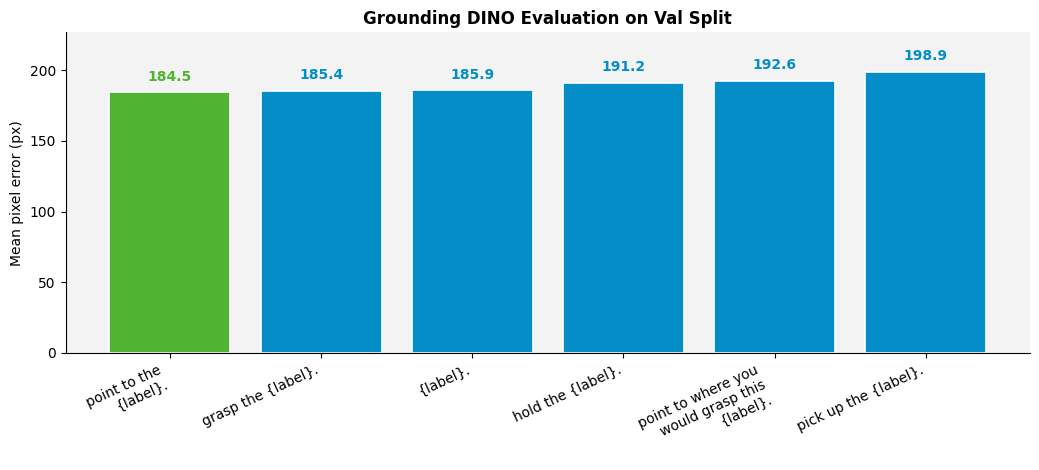

In [ ]:
# Plot the validation mean pixel error for each prompt template.
# This is the primary prompt-selection metric: lower mean pixel error is better.
from textwrap import fill

PPT_BLUE = "#058DC7"
PPT_GREEN = "#50B432"
PPT_ORANGE = "#ED561B"
PPT_LIGHT = "#F3F3F3"
LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 12

templates = [row["template"] for row in summary_rows]
mean_errors = [row["mean_error"] if row["mean_error"] is not None else float("nan") for row in summary_rows]
wrapped_templates = [fill(template, width=20) for template in templates]
bar_colors = [PPT_GREEN] + [PPT_BLUE] * (max(len(templates) - 1, 0))
y_max = max(mean_errors) if mean_errors else 1.0

fig, ax = plt.subplots(figsize=(10.5, 4.8), facecolor="white")
ax.set_facecolor(PPT_LIGHT)
bars = ax.bar(range(len(templates)), mean_errors, color=bar_colors, edgecolor="white", linewidth=1.2)
ax.set_xticks(range(len(templates)))
ax.set_xticklabels(wrapped_templates, rotation=25, ha="right", fontsize=LABEL_FONT_SIZE)
ax.set_ylabel("Mean pixel error (px)", fontsize=LABEL_FONT_SIZE)
ax.set_title(f"Grounding DINO Evaluation on {SPLIT_NAME.capitalize()} Split", fontsize=TITLE_FONT_SIZE, weight="bold")
ax.tick_params(axis="y", labelsize=LABEL_FONT_SIZE)
ax.set_ylim(0, y_max * 1.14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for idx, (bar, value) in enumerate(zip(bars, mean_errors)):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        value + y_max * 0.03,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=LABEL_FONT_SIZE,
        color=PPT_GREEN if idx == 0 else PPT_BLUE,
        weight="bold",
    )

fig.tight_layout()
plt.show()


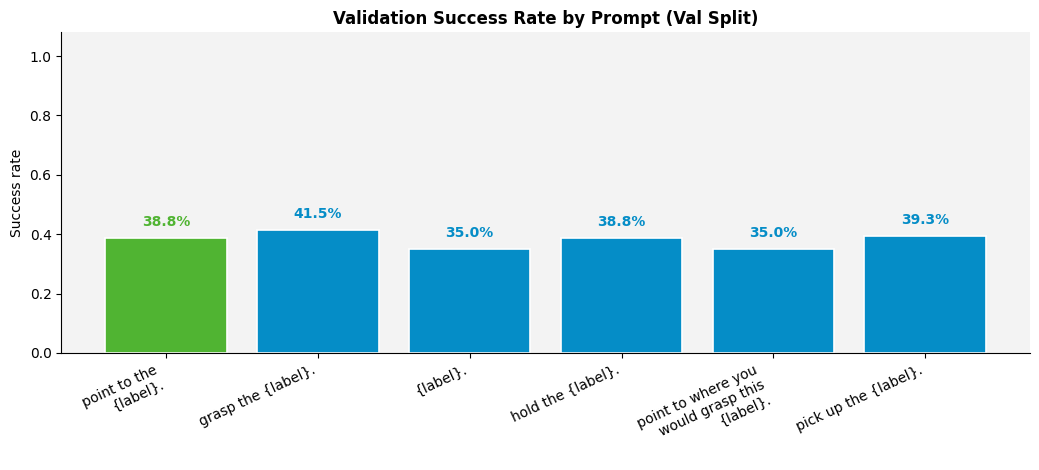

In [ ]:
# Plot the validation success rate for each prompt template.
from textwrap import fill

PPT_BLUE = "#058DC7"
PPT_GREEN = "#50B432"
PPT_LIGHT = "#F3F3F3"
LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 12

templates = [row["template"] for row in summary_rows]
success_rates = [row["success_rate"] if row["success_rate"] is not None else float("nan") for row in summary_rows]
wrapped_templates = [fill(template, width=20) for template in templates]
bar_colors = [PPT_GREEN] + [PPT_BLUE] * (max(len(templates) - 1, 0))

fig, ax = plt.subplots(figsize=(10.5, 4.8), facecolor="white")
ax.set_facecolor(PPT_LIGHT)
bars = ax.bar(range(len(templates)), success_rates, color=bar_colors, edgecolor="white", linewidth=1.2)
ax.set_xticks(range(len(templates)))
ax.set_xticklabels(wrapped_templates, rotation=25, ha="right", fontsize=LABEL_FONT_SIZE)
ax.set_ylabel("Success rate", fontsize=LABEL_FONT_SIZE)
ax.set_title(f"Validation Success Rate by Prompt ({SPLIT_NAME.capitalize()} Split)", fontsize=TITLE_FONT_SIZE, weight="bold")
ax.tick_params(axis="y", labelsize=LABEL_FONT_SIZE)
ax.set_ylim(0.0, 1.08)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for idx, (bar, value) in enumerate(zip(bars, success_rates)):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        min(value + 0.03, 1.03),
        f"{value * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=LABEL_FONT_SIZE,
        color=PPT_GREEN if idx == 0 else PPT_BLUE,
        weight="bold",
    )

fig.tight_layout()
plt.show()


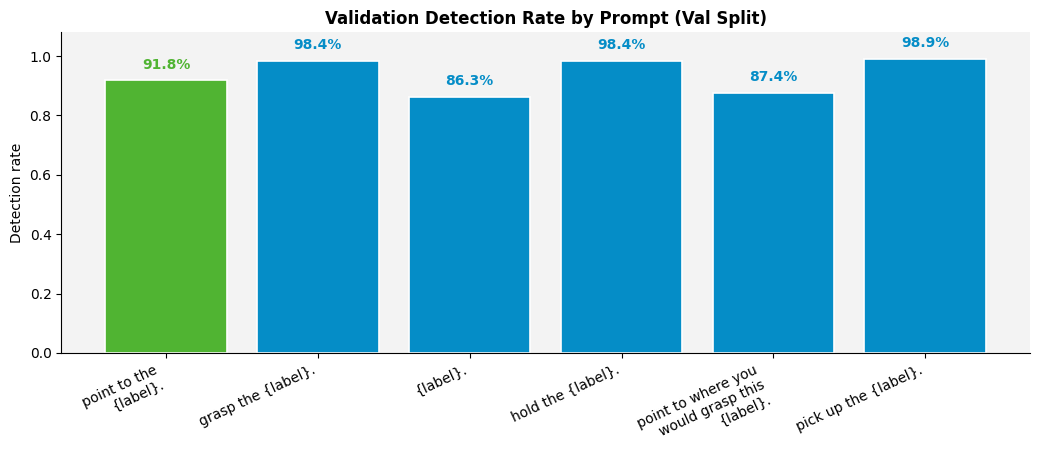

In [ ]:
# Plot the validation detection rate for each prompt template.
from textwrap import fill

PPT_BLUE = "#058DC7"
PPT_GREEN = "#50B432"
PPT_LIGHT = "#F3F3F3"
LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 12

templates = [row["template"] for row in summary_rows]
detection_rates = [row["detection_rate"] if row["detection_rate"] is not None else float("nan") for row in summary_rows]
wrapped_templates = [fill(template, width=20) for template in templates]
bar_colors = [PPT_GREEN] + [PPT_BLUE] * (max(len(templates) - 1, 0))

fig, ax = plt.subplots(figsize=(10.5, 4.8), facecolor="white")
ax.set_facecolor(PPT_LIGHT)
bars = ax.bar(range(len(templates)), detection_rates, color=bar_colors, edgecolor="white", linewidth=1.2)
ax.set_xticks(range(len(templates)))
ax.set_xticklabels(wrapped_templates, rotation=25, ha="right", fontsize=LABEL_FONT_SIZE)
ax.set_ylabel("Detection rate", fontsize=LABEL_FONT_SIZE)
ax.set_title(f"Validation Detection Rate by Prompt ({SPLIT_NAME.capitalize()} Split)", fontsize=TITLE_FONT_SIZE, weight="bold")
ax.tick_params(axis="y", labelsize=LABEL_FONT_SIZE)
ax.set_ylim(0.0, 1.08)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for idx, (bar, value) in enumerate(zip(bars, detection_rates)):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        min(value + 0.03, 1.03),
        f"{value * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=LABEL_FONT_SIZE,
        color=PPT_GREEN if idx == 0 else PPT_BLUE,
        weight="bold",
    )

fig.tight_layout()
plt.show()


### Step 3: Validation Result Analysis

After the sweep, we break the results down by category to understand which object classes are easier or harder for the model during validation.

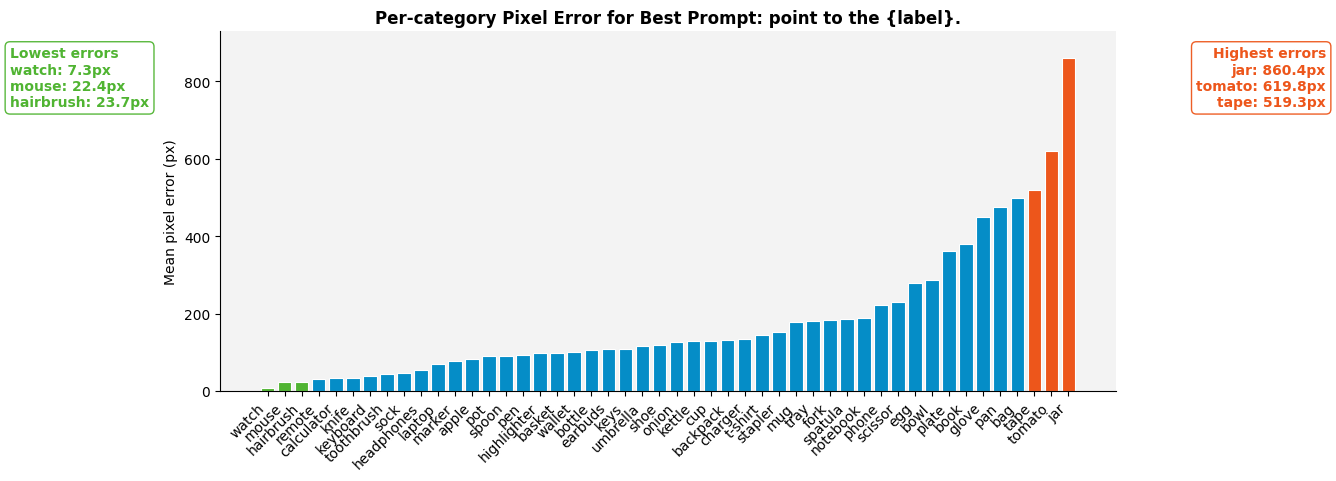

In [ ]:
# Plot the per-category pixel error for the best validation prompt.
PPT_BLUE = "#058DC7"
PPT_GREEN = "#50B432"
PPT_ORANGE = "#ED561B"
PPT_LIGHT = "#F3F3F3"
LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 12

category_rows = best_template_result["per_category"]
cat_labels = [row["label"] for row in category_rows]
cat_errors = [row["mean_error"] if row["mean_error"] is not None else float("nan") for row in category_rows]
cat_colors = []
for idx in range(len(cat_labels)):
    if idx < 3:
        cat_colors.append(PPT_GREEN)
    elif idx >= len(cat_labels) - 3:
        cat_colors.append(PPT_ORANGE)
    else:
        cat_colors.append(PPT_BLUE)

y_max = max(cat_errors) if cat_errors else 1.0
fig, ax = plt.subplots(figsize=(14, 5.8), facecolor="white")
fig.subplots_adjust(top=0.86, bottom=0.24, left=0.18, right=0.82)
ax.set_facecolor(PPT_LIGHT)
ax.bar(range(len(cat_labels)), cat_errors, color=cat_colors, edgecolor="white", linewidth=0.8)
ax.set_xticks(range(len(cat_labels)))
ax.set_xticklabels(cat_labels, rotation=45, ha="right", fontsize=LABEL_FONT_SIZE)
ax.set_ylabel("Mean pixel error (px)", fontsize=LABEL_FONT_SIZE)
ax.set_title(f"Per-category Pixel Error for Best Prompt: {BEST_TEMPLATE}", fontsize=TITLE_FONT_SIZE, weight="bold")
ax.tick_params(axis="y", labelsize=LABEL_FONT_SIZE)
ax.set_ylim(0, y_max * 1.08)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

lowest_rows = category_rows[:3]
highest_rows = category_rows[-3:]
lowest_text = "Lowest errors\n" + "\n".join(f"{row['label']}: {row['mean_error']:.1f}px" for row in lowest_rows)
highest_text = "Highest errors\n" + "\n".join(f"{row['label']}: {row['mean_error']:.1f}px" for row in reversed(highest_rows))

fig.text(
    0.03,
    0.78,
    lowest_text,
    va="center",
    ha="left",
    fontsize=LABEL_FONT_SIZE,
    color=PPT_GREEN,
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=PPT_GREEN, alpha=0.95),
)
fig.text(
    0.97,
    0.78,
    highest_text,
    va="center",
    ha="right",
    fontsize=LABEL_FONT_SIZE,
    color=PPT_ORANGE,
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=PPT_ORANGE, alpha=0.95),
)

plt.show()


### Step 4: Qualitative Prompt Comparison

This section visually compares prompts on the same sample to explain why some prompt formulations perform better than others.

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:98: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


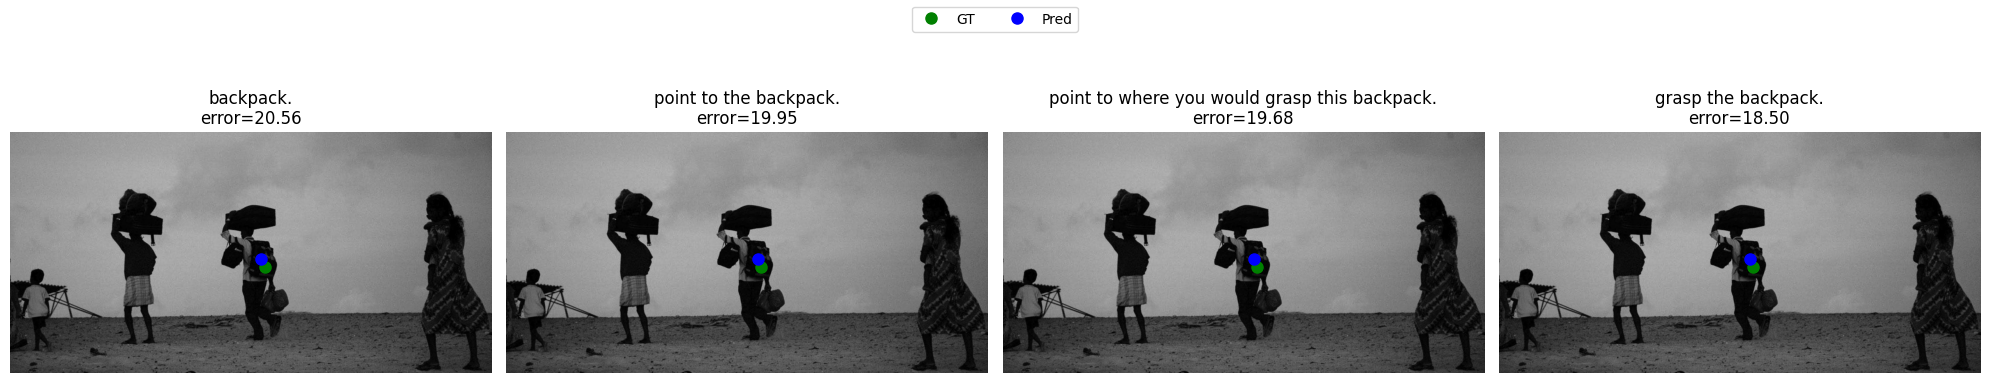

In [ ]:
# Define a helper to compare prompt behavior qualitatively on one sample.
def visualize_prompt_comparison(sample_row, templates_to_show=None):
    if templates_to_show is None:
        templates_to_show = prompt_templates[:4]

    filename = os.path.basename(sample_row["image_path"])
    sample_image = Image.open(IMAGES_DIR / filename).convert("RGB")
    gt_x, gt_y = get_first_gt_point(sample_row)
    sample_w, sample_h = sample_image.size
    gt_x_px = (gt_x / 100.0) * sample_w
    gt_y_px = (gt_y / 100.0) * sample_h

    fig, axes = plt.subplots(1, len(templates_to_show), figsize=(5 * len(templates_to_show), 5))
    if len(templates_to_show) == 1:
        axes = [axes]

    for ax, template in zip(axes, templates_to_show):
        prompt = template.format(label=sample_row["label"])
        row = run_grounding_dino_on_sample(sample_row, prompt)
        ax.imshow(sample_image)
        ax.plot(gt_x_px, gt_y_px, "go", markersize=8, label="GT")

        if row["pred_point"] is not None:
            pred_x_px, pred_y_px = row["pred_point"]
            ax.plot(pred_x_px, pred_y_px, "bo", markersize=8, label="Pred")
            ax.set_title(f"{prompt}\nerror={row['error']:.2f}")
        else:
            ax.set_title(f"{prompt}\nno detection")

        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)
    plt.tight_layout()
    plt.show()

QUAL_SAMPLE_INDEX = 5
visualize_prompt_comparison(pointing_samples[QUAL_SAMPLE_INDEX])


### Step 5: Save Validation Outputs

Here we save the validation summaries and detailed results so the best prompt can be reused later without rerunning the full sweep.

In [ ]:
# Ensure the output directory exists before saving any result files.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTPUT_DIR)


Output directory: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error


In [ ]:
# Convert notebook results into JSON-safe types before exporting.
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(key): make_json_safe(value) for key, value in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(item) for item in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(item) for item in obj]
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except Exception:
            pass
    if isinstance(obj, float) and math.isnan(obj):
        return None
    return obj

In [ ]:
# Save the validation prompt-evaluation outputs to disk.
results_path = OUTPUT_DIR / f"grounding_dino_{SPLIT_NAME}_prompt_eval.json"
summary_path = OUTPUT_DIR / f"grounding_dino_{SPLIT_NAME}_prompt_summary.json"
per_category_path = OUTPUT_DIR / f"grounding_dino_{SPLIT_NAME}_final_per_category.json"

# Ensure the output directory exists right before writing
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

safe_all_results = make_json_safe(all_results)
safe_summary_rows = make_json_safe(summary_rows)
safe_best_template_result = make_json_safe(best_template_result)

with open(results_path, "w", encoding="utf-8") as f:
    json.dump(safe_all_results, f, indent=2)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(safe_summary_rows, f, indent=2)

with open(per_category_path, "w", encoding="utf-8") as f:
    json.dump(safe_best_template_result, f, indent=2)

print("Saved detailed results to:", results_path)
print("Saved summary to:", summary_path)
print("Saved best-prompt per-category results to:", per_category_path)

Saved detailed results to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_val_prompt_eval.json
Saved summary to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_val_prompt_summary.json
Saved best-prompt per-category results to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_val_final_per_category.json


## Phase 5: Test Evaluation and Robustness Analysis

In this phase, we evaluate the best validation prompt on the test split, export the results, visualize diagnostics, and run a broader prompt sweep to study robustness and prompt sensitivity on held-out data.

In [ ]:
# Load the best validation prompt and prepare the final test split.
FINAL_TEST_SPLIT = "test"
FINAL_TEST_SUCCESS_RADIUS = 50.0

# Pick the final test prompt from validation using the lowest mean pixel error instead of hardcoding it.
if "summary_rows" in globals() and summary_rows:
    FINAL_TEST_PROMPT_TEMPLATE = summary_rows[0]["template"]
else:
    val_final_summary_path = OUTPUT_DIR / "grounding_dino_val_final_summary.json"
    with open(val_final_summary_path, "r", encoding="utf-8") as f:
        val_final_summary = json.load(f)
    FINAL_TEST_PROMPT_TEMPLATE = val_final_summary["best_prompt"]

final_test_split_path = SPLITS_DIR / f"{FINAL_TEST_SPLIT}.json"
with open(final_test_split_path, "r", encoding="utf-8") as f:
    final_test_data = json.load(f)

final_test_pointing_samples = [
    row for row in final_test_data
    if row.get("collection_method") == "pointing"
]

print("FINAL_TEST_SPLIT:", FINAL_TEST_SPLIT)
print("FINAL_TEST_PROMPT_TEMPLATE:", FINAL_TEST_PROMPT_TEMPLATE)
print("Pointing samples in test split:", len(final_test_pointing_samples))


FINAL_TEST_SPLIT: test
FINAL_TEST_PROMPT_TEMPLATE: point to the {label}.
Pointing samples in test split: 183


In [ ]:
# Run final test inference using the prompt selected on validation.
final_test_rows = []

for sample_row in final_test_pointing_samples:
    prompt = FINAL_TEST_PROMPT_TEMPLATE.format(label=sample_row["label"])
    row = run_grounding_dino_on_sample(sample_row, prompt)
    final_test_rows.append(row)

final_test_valid_rows = [row for row in final_test_rows if row.get("error") is not None]
final_test_mean_error = (
    sum(row["error"] for row in final_test_valid_rows) / len(final_test_valid_rows)
    if final_test_valid_rows else None
)
final_test_mean_normalized_error = (
    sum(row["normalized_error"] for row in final_test_valid_rows) / len(final_test_valid_rows)
    if final_test_valid_rows else None
)
final_test_success_rate = (
    sum(1 for row in final_test_rows if row.get("error") is not None and row["error"] <= FINAL_TEST_SUCCESS_RADIUS) / len(final_test_rows)
    if final_test_rows else None
)
final_test_detection_rate = (
    sum(1 for row in final_test_rows if row["status"] == "ok") / len(final_test_rows)
    if final_test_rows else None
)

final_test_summary = {
    "split": FINAL_TEST_SPLIT,
    "prompt_template": FINAL_TEST_PROMPT_TEMPLATE,
    "num_samples": len(final_test_rows),
    "num_valid": len(final_test_valid_rows),
    "mean_error": final_test_mean_error,
    "mean_normalized_error": final_test_mean_normalized_error,
    "success_rate": final_test_success_rate,
    "detection_rate": final_test_detection_rate,
}

final_test_summary

{'split': 'test',
 'prompt_template': 'point to the {label}.',
 'num_samples': 183,
 'num_valid': 162,
 'mean_error': 215.3543276734404,
 'mean_normalized_error': 0.12625134017557813,
 'success_rate': 0.32786885245901637,
 'detection_rate': 0.8852459016393442}

### Presentation View: Test Evaluation

We freeze the best validation prompt and evaluate it on the unseen test split. These figures summarize final performance and highlight the most important metrics to discuss during the demo.


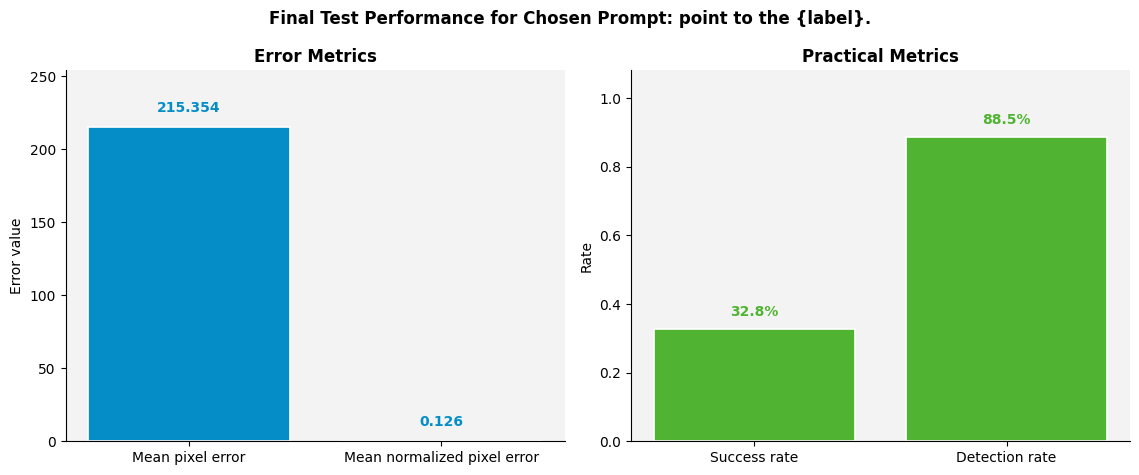

In [ ]:
# Plot the final test summary metrics for the chosen prompt.
PPT_BLUE = "#058DC7"
PPT_GREEN = "#50B432"
PPT_LIGHT = "#F3F3F3"
LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 12

error_metric_labels = ["Mean pixel error", "Mean normalized pixel error"]
error_metric_values = [final_test_summary["mean_error"], final_test_summary["mean_normalized_error"]]
rate_metric_labels = ["Success rate", "Detection rate"]
rate_metric_values = [final_test_summary["success_rate"], final_test_summary["detection_rate"]]
error_y_max = max(error_metric_values) if error_metric_values else 1.0

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), facecolor="white")
for ax in axes:
    ax.set_facecolor(PPT_LIGHT)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=LABEL_FONT_SIZE)

error_bars = axes[0].bar(range(len(error_metric_labels)), error_metric_values, color=PPT_BLUE, edgecolor="white", linewidth=1.2)
axes[0].set_xticks(range(len(error_metric_labels)))
axes[0].set_xticklabels(error_metric_labels, fontsize=LABEL_FONT_SIZE)
axes[0].set_ylabel("Error value", fontsize=LABEL_FONT_SIZE)
axes[0].set_title("Error Metrics", fontsize=TITLE_FONT_SIZE, weight="bold")
axes[0].set_ylim(0, error_y_max * 1.18)
for bar, value in zip(error_bars, error_metric_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2.0, value + error_y_max * 0.04, f"{value:.3f}", ha="center", va="bottom", fontsize=LABEL_FONT_SIZE, color=PPT_BLUE, weight="bold")

rate_bars = axes[1].bar(range(len(rate_metric_labels)), rate_metric_values, color=PPT_GREEN, edgecolor="white", linewidth=1.2)
axes[1].set_xticks(range(len(rate_metric_labels)))
axes[1].set_xticklabels(rate_metric_labels, fontsize=LABEL_FONT_SIZE)
axes[1].set_ylim(0.0, 1.08)
axes[1].set_ylabel("Rate", fontsize=LABEL_FONT_SIZE)
axes[1].set_title("Practical Metrics", fontsize=TITLE_FONT_SIZE, weight="bold")
for bar, value in zip(rate_bars, rate_metric_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2.0, min(value + 0.03, 1.03), f"{value * 100:.1f}%", ha="center", va="bottom", fontsize=LABEL_FONT_SIZE, color=PPT_GREEN, weight="bold")

fig.suptitle(f"Final Test Performance for Chosen Prompt: {FINAL_TEST_PROMPT_TEMPLATE}", fontsize=TITLE_FONT_SIZE, weight="bold")
fig.tight_layout()
plt.show()


In [ ]:
# Summarize the final test results by object category.
final_test_per_category = []

for label_name in sorted({row["label"] for row in final_test_rows}):
    label_rows = [row for row in final_test_rows if row["label"] == label_name]
    label_valid = [row for row in label_rows if row.get("error") is not None]
    final_test_per_category.append({
        "label": label_name,
        "num_samples": len(label_rows),
        "num_valid": len(label_valid),
        "mean_error": sum(row["error"] for row in label_valid) / len(label_valid) if label_valid else None,
        "mean_normalized_error": sum(row["normalized_error"] for row in label_valid) / len(label_valid) if label_valid else None,
        "success_rate": (
            sum(1 for row in label_rows if row.get("error") is not None and row["error"] <= FINAL_TEST_SUCCESS_RADIUS) / len(label_rows)
            if label_rows else None
        ),
        "detection_rate": (
            sum(1 for row in label_rows if row["status"] == "ok") / len(label_rows)
            if label_rows else None
        ),
    })

final_test_per_category = sorted(
    final_test_per_category,
    key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
)

final_test_per_category[:10]

[{'label': 'mouse',
  'num_samples': 4,
  'num_valid': 2,
  'mean_error': 7.36389996749665,
  'mean_normalized_error': 0.0077334376934780485,
  'success_rate': 0.5,
  'detection_rate': 0.5},
 {'label': 'remote',
  'num_samples': 4,
  'num_valid': 2,
  'mean_error': 15.663065630576526,
  'mean_normalized_error': 0.01043684539052683,
  'success_rate': 0.5,
  'detection_rate': 0.5},
 {'label': 'bottle',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 28.70269904668939,
  'mean_normalized_error': 0.028543532394633347,
  'success_rate': 1.0,
  'detection_rate': 1.0},
 {'label': 'shoe',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 34.138457223163584,
  'mean_normalized_error': 0.047221357424845095,
  'success_rate': 0.75,
  'detection_rate': 1.0},
 {'label': 'watch',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 41.61617123963368,
  'mean_normalized_error': 0.029414469345237598,
  'success_rate': 0.5,
  'detection_rate': 0.75},
 {'label': 'egg',
  'num_samples': 4,
  '

### Presentation View: Category and Failure Analysis

We inspect which categories are easiest and hardest on the test split, then look at the error distribution to understand whether a few difficult cases dominate the final average.


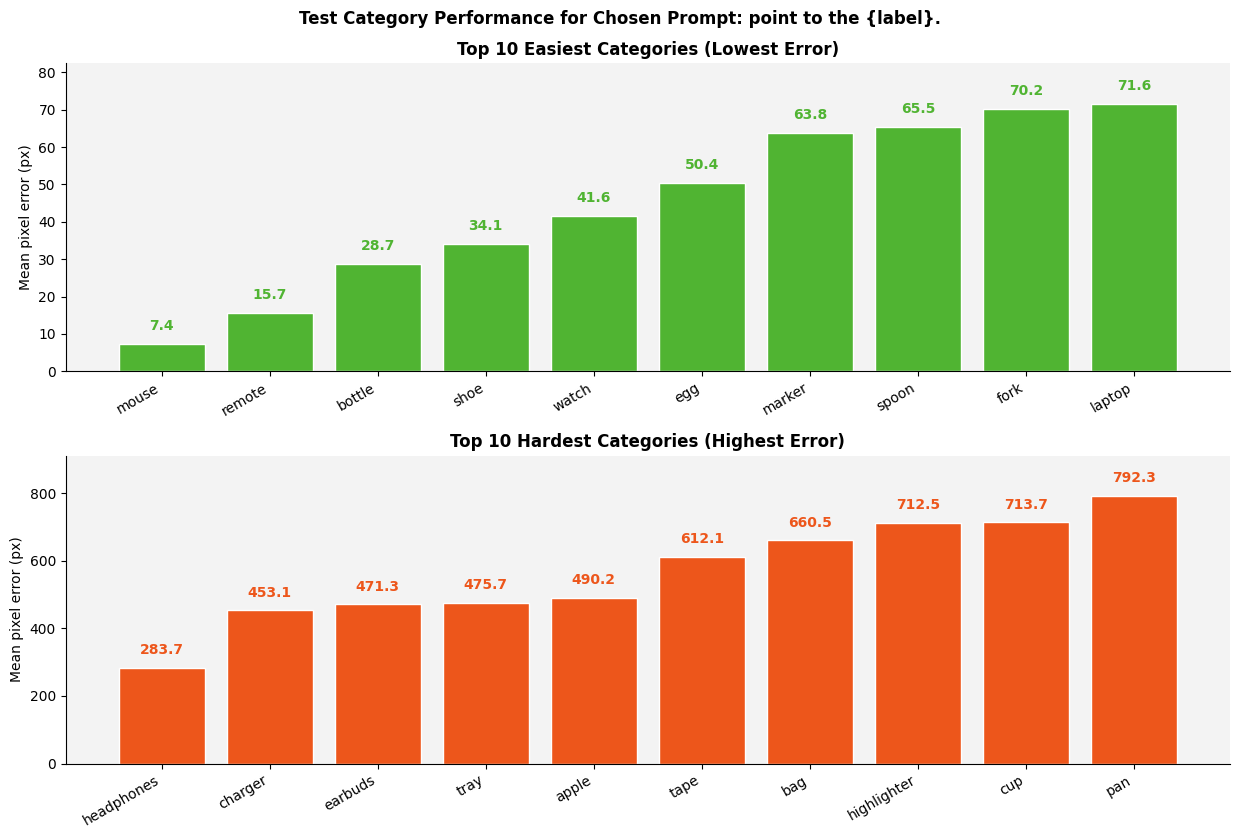

In [ ]:
# Plot the easiest and hardest test categories for the chosen prompt.
PPT_BLUE = "#058DC7"
PPT_GREEN = "#50B432"
PPT_ORANGE = "#ED561B"
PPT_LIGHT = "#F3F3F3"
LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 12

valid_category_rows = [row for row in final_test_per_category if row["mean_error"] is not None]
easiest_rows = valid_category_rows[:10]
hardest_rows = valid_category_rows[-10:]

fig, axes = plt.subplots(2, 1, figsize=(12.5, 8.5), facecolor="white")
panel_specs = [
    (axes[0], easiest_rows, PPT_GREEN, "Top 10 Easiest Categories (Lowest Error)"),
    (axes[1], hardest_rows, PPT_ORANGE, "Top 10 Hardest Categories (Highest Error)"),
]

for ax, rows, color, title in panel_specs:
    labels = [row["label"] for row in rows]
    values = [row["mean_error"] for row in rows]
    y_max = max(values) if values else 1.0
    ax.set_facecolor(PPT_LIGHT)
    bars = ax.bar(range(len(labels)), values, color=color, edgecolor="white", linewidth=1.0)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel("Mean pixel error (px)", fontsize=LABEL_FONT_SIZE)
    ax.set_title(title, fontsize=TITLE_FONT_SIZE, weight="bold")
    ax.tick_params(axis="y", labelsize=LABEL_FONT_SIZE)
    ax.set_ylim(0, y_max * 1.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2.0, value + y_max * 0.04, f"{value:.1f}", ha="center", va="bottom", fontsize=LABEL_FONT_SIZE, color=color, weight="bold")

fig.suptitle(f"Test Category Performance for Chosen Prompt: {FINAL_TEST_PROMPT_TEMPLATE}", fontsize=TITLE_FONT_SIZE, weight="bold")
fig.tight_layout()
plt.show()


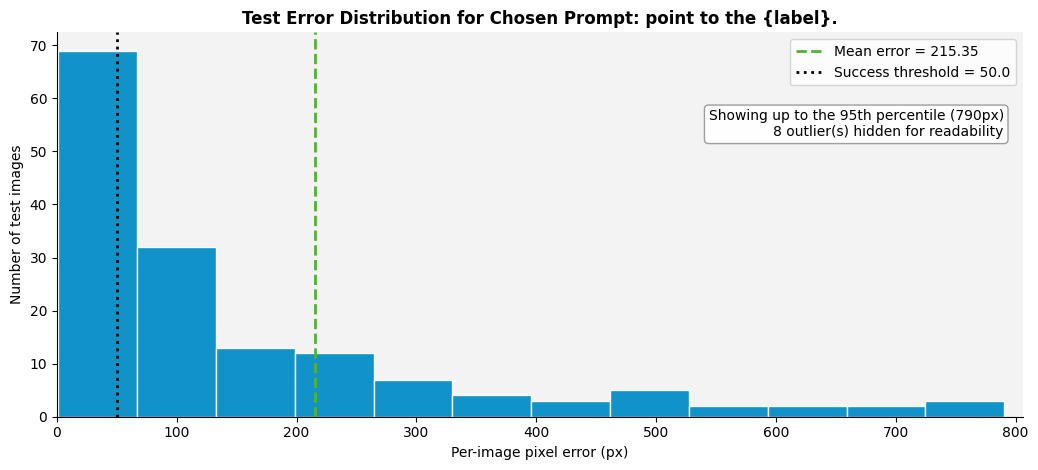

In [ ]:
# Plot the distribution of per-image test errors for the chosen prompt.
PPT_BLUE = "#058DC7"
PPT_GREEN = "#50B432"
PPT_LIGHT = "#F3F3F3"
LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 12

test_errors = [row["error"] for row in final_test_rows if row.get("error") is not None]
if test_errors:
    sorted_errors = sorted(test_errors)
    percentile_idx = max(0, math.ceil(0.95 * len(sorted_errors)) - 1)
    display_limit = sorted_errors[percentile_idx]
else:
    display_limit = 0.0
plot_errors = [err for err in test_errors if err <= display_limit]
num_clipped = len(test_errors) - len(plot_errors)

fig, ax = plt.subplots(figsize=(10.5, 4.8), facecolor="white")
ax.set_facecolor(PPT_LIGHT)
ax.hist(plot_errors, bins=12, color=PPT_BLUE, edgecolor="white", linewidth=1.0, alpha=0.95)

mean_error = final_test_summary["mean_error"]
if mean_error <= display_limit:
    ax.axvline(mean_error, color=PPT_GREEN, linestyle="--", linewidth=2, label=f"Mean error = {mean_error:.2f}")
else:
    ax.axvline(display_limit, color=PPT_GREEN, linestyle="--", linewidth=2, label=f"Mean error = {mean_error:.2f} (off scale)")

ax.axvline(FINAL_TEST_SUCCESS_RADIUS, color="#000000", linestyle=":", linewidth=2, label=f"Success threshold = {FINAL_TEST_SUCCESS_RADIUS:.1f}")
ax.set_xlim(0, display_limit * 1.02 if display_limit > 0 else 1)
ax.set_xlabel("Per-image pixel error (px)", fontsize=LABEL_FONT_SIZE)
ax.set_ylabel("Number of test images", fontsize=LABEL_FONT_SIZE)
ax.set_title(f"Test Error Distribution for Chosen Prompt: {FINAL_TEST_PROMPT_TEMPLATE}", fontsize=TITLE_FONT_SIZE, weight="bold")
ax.tick_params(axis="both", labelsize=LABEL_FONT_SIZE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=LABEL_FONT_SIZE)

note_text = f"Showing up to the 95th percentile ({display_limit:.0f}px)"
if num_clipped > 0:
    note_text += f"\n{num_clipped} outlier(s) hidden for readability"
ax.text(
    0.98,
    0.80,
    note_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=LABEL_FONT_SIZE,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#999999", alpha=0.95),
)

fig.tight_layout()
plt.show()


In [ ]:
# Save the raw final test summaries and detailed predictions.
final_test_summary_path = OUTPUT_DIR / "grounding_dino_test_raw_summary.json"
final_test_details_path = OUTPUT_DIR / "grounding_dino_test_raw_details.json"
final_test_per_category_path = OUTPUT_DIR / "grounding_dino_test_final_per_category.json"

with open(final_test_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(final_test_summary), f, indent=2)

with open(final_test_details_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(final_test_rows), f, indent=2)

with open(final_test_per_category_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(final_test_per_category), f, indent=2)

print("Saved raw test summary to:", final_test_summary_path)
print("Saved raw test details to:", final_test_details_path)
print("Saved final test per-category results to:", final_test_per_category_path)

Saved raw test summary to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_raw_summary.json
Saved raw test details to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_raw_details.json
Saved final test per-category results to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_final_per_category.json


### Step 1: Export Test Results

This section writes a flatter JSON output for downstream analysis, separating per-sample records from aggregate summaries.

In [ ]:
# Build flat per-image records for downstream analysis and reporting.
def build_flat_sample_records(rows, split_name, success_radius, best_prompt_name=None):
    flat_records = []
    for row in rows:
        gt_x = row["gt_point"][0] if row.get("gt_point") is not None else None
        gt_y = row["gt_point"][1] if row.get("gt_point") is not None else None
        pred_x = row["pred_point"][0] if row.get("pred_point") is not None else None
        pred_y = row["pred_point"][1] if row.get("pred_point") is not None else None
        pixel_error = row.get("error")
        normalized_pixel_error = row.get("normalized_error")
        success = None if pixel_error is None else int(pixel_error <= success_radius)

        flat_records.append({
            "split": split_name,
            "image_path": str(IMAGES_DIR / row["filename"]),
            "label": row["label"],
            "prompt": row.get("prompt"),
            "pred_x": pred_x,
            "pred_y": pred_y,
            "gt_x": gt_x,
            "gt_y": gt_y,
            "pixel_error": pixel_error,
            "normalized_pixel_error": normalized_pixel_error,
            "success": success,
            "status": row.get("status"),
            "score": row.get("score"),
            "best_label": row.get("best_label"),
            "best_prompt_from_val": best_prompt_name,
            "prompt_sensitivity": None,
            "prompt_consistency": None,
        })
    return flat_records

In [ ]:
# Export the validation records and attach prompt-level consistency metrics.
val_best_prompt_name = summary_rows[0]["template"] if "summary_rows" in globals() and summary_rows else None
val_best_prompt_rows = []
if "all_results" in globals() and val_best_prompt_name is not None:
    val_best_prompt_rows = next(item["details"] for item in all_results if item["template"] == val_best_prompt_name)

flat_val_records = build_flat_sample_records(
    val_best_prompt_rows,
    split_name="val",
    success_radius=SUCCESS_RADIUS,
    best_prompt_name=val_best_prompt_name,
)

# Compute prompt-level metrics: sensitivity (stddev of per-prompt mean error) and consistency (avg fraction of prompts that succeed per sample)
from statistics import pstdev, mean
# collect mean errors per prompt (exclude None)
prompt_mean_errors = [r['mean_error'] for r in summary_rows if r.get('mean_error') is not None]
prompt_sensitivity = float(pstdev(prompt_mean_errors)) if len(prompt_mean_errors) > 0 else None

# compute per-sample success counts across all prompts
sample_success_counts = {}
all_sample_ids = set()
num_prompts = len(all_results)
for templ in all_results:
    for row in templ['details']:
        sid = row['id']
        all_sample_ids.add(sid)
        ok = 1 if (row.get('error') is not None and row.get('error') <= SUCCESS_RADIUS) else 0
        sample_success_counts[sid] = sample_success_counts.get(sid, 0) + ok

per_sample_consistency = {sid: (sample_success_counts.get(sid, 0) / num_prompts) for sid in all_sample_ids}
prompt_consistency = float(mean(per_sample_consistency.values())) if per_sample_consistency else None

# attach prompt metrics to flat records: per-image prompt_consistency (per-sample fraction) and global prompt_sensitivity
id_to_consistency = per_sample_consistency
for rec in flat_val_records:
    sid = None
    # try to get id from filename by matching against pointing_samples
    for s in pointing_samples:
        if os.path.basename(s['image_path']) == os.path.basename(rec['image_path']):
            sid = s.get('id')
            break
    rec['prompt_sensitivity'] = prompt_sensitivity
    rec['prompt_consistency'] = id_to_consistency.get(sid, None) if sid is not None else None

flat_val_summary = {
    "split": "val",
    "best_prompt": val_best_prompt_name,
    "success_rate": next((row["success_rate"] for row in summary_rows if row["template"] == val_best_prompt_name), None),
    "per_prompt_error": {row["template"]: row["mean_error"] for row in summary_rows},
    "per_category_error": {row["label"]: row["mean_error"] for row in best_template_result["per_category"]},
    "prompt_sensitivity": prompt_sensitivity,
    "prompt_consistency": prompt_consistency,
    "per_prompt_normalized_error": {row["template"]: row["mean_normalized_error"] for row in summary_rows},
    "per_prompt_success_rate": {row["template"]: row["success_rate"] for row in summary_rows},
    "per_prompt_detection_rate": {row["template"]: row["detection_rate"] for row in summary_rows},
}

flat_val_path = OUTPUT_DIR / "grounding_dino_val_final_per_image.json"
flat_val_summary_path = OUTPUT_DIR / "grounding_dino_val_final_summary.json"

with open(flat_val_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_val_records), f, indent=2)

with open(flat_val_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_val_summary), f, indent=2)

print("Saved final val records to:", flat_val_path)
print("Saved final val summary to:", flat_val_summary_path)
flat_val_summary


Saved final val records to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_val_final_per_image.json
Saved final val summary to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_val_final_summary.json


{'split': 'val',
 'best_prompt': 'point to the {label}.',
 'success_rate': 0.3879781420765027,
 'per_prompt_error': {'point to the {label}.': 184.4730849499086,
  'grasp the {label}.': 185.38803956061884,
  '{label}.': 185.85212625732862,
  'hold the {label}.': 191.18882486432634,
  'point to where you would grasp this {label}.': 192.58729006883576,
  'pick up the {label}.': 198.9481489858626},
 'per_category_error': {'watch': 7.338364806045566,
  'mouse': 22.40340147470978,
  'hairbrush': 23.739794749034388,
  'remote': 30.448884717570664,
  'calculator': 32.62888154295392,
  'knife': 33.35610281987988,
  'keyboard': 38.96897718029338,
  'toothbrush': 44.610538097808856,
  'sock': 47.494302116020634,
  'headphones': 54.47120519384505,
  'laptop': 70.46252214497063,
  'marker': 77.35892746800313,
  'apple': 82.53013746825063,
  'pot': 90.7798332272413,
  'spoon': 91.85427062515976,
  'pen': 92.70833482335269,
  'highlighter': 98.15934643411707,
  'basket': 98.8585679797604,
  'wallet':

In [ ]:
# Export the final test records and summary in a flat JSON format.
flat_test_records = build_flat_sample_records(
    final_test_rows,
    split_name="test",
    success_radius=FINAL_TEST_SUCCESS_RADIUS,
    best_prompt_name=FINAL_TEST_PROMPT_TEMPLATE,
)

flat_test_summary = {
    "split": "test",
    "best_prompt": FINAL_TEST_PROMPT_TEMPLATE,
    "success_rate": final_test_summary["success_rate"],
    "per_prompt_error": {FINAL_TEST_PROMPT_TEMPLATE: final_test_summary["mean_error"]},
    "per_category_error": {row["label"]: row["mean_error"] for row in final_test_per_category},
    "prompt_sensitivity": prompt_sensitivity,
    "prompt_consistency": prompt_consistency,
}

flat_test_path = OUTPUT_DIR / "grounding_dino_test_final_per_image.json"
flat_test_summary_path = OUTPUT_DIR / "grounding_dino_test_final_summary.json"

with open(flat_test_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_test_records), f, indent=2)

with open(flat_test_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_test_summary), f, indent=2)

print("Saved final test records to:", flat_test_path)
print("Saved final test summary to:", flat_test_summary_path)
flat_test_records[:2]

Saved final test records to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_final_per_image.json
Saved final test summary to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_final_summary.json


[{'split': 'test',
  'image_path': '/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3/images/apple_8.jpg',
  'label': 'apple',
  'prompt': 'point to the apple.',
  'pred_x': None,
  'pred_y': None,
  'gt_x': 263.8095238095238,
  'gt_y': 446.6666666666667,
  'pixel_error': None,
  'normalized_pixel_error': None,
  'success': None,
  'status': 'no_detection',
  'score': None,
  'best_label': None,
  'best_prompt_from_val': 'point to the {label}.',
  'prompt_sensitivity': None,
  'prompt_consistency': None},
 {'split': 'test',
  'image_path': '/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3/images/apple_9.jpg',
  'label': 'apple',
  'prompt': 'point to the apple.',
  'pred_x': None,
  'pred_y': None,
  'gt_x': 195.23809523809524,
  'gt_y': 429.5238095238095,
  'pixel_error': None,
  'normalized_pixel_error': None,
  'success': None,
  'status': 'no_detection',
  'score': None,
  'best_label': None,
  'best_prompt_from_val': 'point to the {label}.',
  'p

### Step 2: Diagnostic Visualization

Here we inspect detailed predictions for selected samples to better understand successes, failures, and box ranking behavior.

In [ ]:
# Load and visualize detailed diagnostics for one selected sample.
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Select sample: optionally set SAMPLE_ID (int) or SAMPLE_INDEX (int). If both unset, pick first non-apple sample.
SAMPLE_ID = None  # e.g. 9 (leave None to auto-select)
SAMPLE_INDEX = None  # leave None to auto-select first non-apple sample
TOPK = 5

if 'pointing_samples' not in globals():
    raise RuntimeError('pointing_samples not found Ã¢â‚¬â€ run the Load One Split cell first')

# If no sample is specified, pick a default example that is usually more informative to inspect.
if SAMPLE_ID is None and SAMPLE_INDEX is None:
    SAMPLE_INDEX = next((i for i, r in enumerate(pointing_samples) if r.get('label') != 'apple'), 0)

# Locate the sample row from either an explicit id or an index into the split.
sample_row = None
if SAMPLE_ID is not None:
    for r in pointing_samples:
        if r.get('id') == SAMPLE_ID:
            sample_row = r
            break
else:
    if SAMPLE_INDEX < 0 or SAMPLE_INDEX >= len(pointing_samples):
        raise IndexError('SAMPLE_INDEX out of range')
    sample_row = pointing_samples[SAMPLE_INDEX]

sample_id = sample_row.get('id')
filename = os.path.basename(sample_row['image_path'])

diag_path = OUTPUT_DIR / f'diagnostics_sample_{sample_id}_topk.json' if 'OUTPUT_DIR' in globals() else Path(f'outputs/grounding_dino_from_scratch/diagnostics_sample_{sample_id}_topk.json')

def safe_label(x):
    try:
        import torch
        if hasattr(x, 'detach'):
            x = x.detach().cpu().item() if x.numel() == 1 else x.detach().cpu().tolist()
    except Exception:
        pass
    return x

### Step 3: Robust Test Prompt Sweep

This section reruns multiple prompts on the test split so we can compare prompt sensitivity and consistency beyond a single best prompt.

In [ ]:
# Load the test split again for a multi-prompt robustness sweep.
ROBUST_TEST_SPLIT = "test"
ROBUST_TEST_PROMPT_TEMPLATES = [
    "{label}.",
    "point to the {label}.",
    "point to where you would grasp this {label}.",
    "grasp the {label}.",
    "hold the {label}.",
    "pick up the {label}.",
]
ROBUST_TEST_SUCCESS_RADIUS = 50.0

robust_test_split_path = SPLITS_DIR / f"{ROBUST_TEST_SPLIT}.json"
with open(robust_test_split_path, "r", encoding="utf-8") as f:
    robust_test_data = json.load(f)

robust_test_pointing_samples = [
    row for row in robust_test_data
    if row.get("collection_method") == "pointing"
]

print("ROBUST_TEST_SPLIT:", ROBUST_TEST_SPLIT)
print("Prompt templates:", ROBUST_TEST_PROMPT_TEMPLATES)
print("Pointing samples in robust test split:", len(robust_test_pointing_samples))


ROBUST_TEST_SPLIT: test
Prompt templates: ['{label}.', 'point to the {label}.', 'point to where you would grasp this {label}.', 'grasp the {label}.', 'hold the {label}.', 'pick up the {label}.']
Pointing samples in robust test split: 183


In [ ]:
# Run all prompt templates on the test split for robustness comparison.
robust_test_all_results = []

for template in ROBUST_TEST_PROMPT_TEMPLATES:
    template_results = []
    for sample_row in robust_test_pointing_samples:
        prompt = template.format(label=sample_row["label"])
        row = run_grounding_dino_on_sample(sample_row, prompt)
        template_results.append(row)

    valid_errors = [row.get("error") for row in template_results if row.get("error") is not None]
    valid_norm_errors = [row.get("normalized_error") for row in template_results if row.get("normalized_error") is not None]
    success_count = sum(1 for row in template_results if row.get("error") is not None and row.get("error") <= ROBUST_TEST_SUCCESS_RADIUS)
    detection_count = sum(1 for row in template_results if row.get("status") == "ok")

    robust_test_all_results.append({
        "template": template,
        "mean_error": sum(valid_errors) / len(valid_errors) if valid_errors else None,
        "mean_normalized_error": sum(valid_norm_errors) / len(valid_norm_errors) if valid_norm_errors else None,
        "success_rate": success_count / len(template_results) if template_results else None,
        "detection_rate": detection_count / len(template_results) if template_results else None,
        "details": template_results,
    })

robust_test_summary_rows = sorted(
    [
        {
            "template": item["template"],
            "mean_error": item["mean_error"],
            "mean_normalized_error": item["mean_normalized_error"],
            "success_rate": item["success_rate"],
            "detection_rate": item["detection_rate"],
            "num_samples": len(item["details"]),
            "num_valid": sum(1 for row in item["details"] if row.get("error") is not None),
        }
        for item in robust_test_all_results
    ],
    key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
)

robust_test_summary_rows

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:98: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


[{'template': 'hold the {label}.',
  'mean_error': 199.14240571693645,
  'mean_normalized_error': 0.11986464048917687,
  'success_rate': 0.37158469945355194,
  'detection_rate': 0.9726775956284153,
  'num_samples': 183,
  'num_valid': 178},
 {'template': 'point to where you would grasp this {label}.',
  'mean_error': 201.82061225019254,
  'mean_normalized_error': 0.12236285636190332,
  'success_rate': 0.3333333333333333,
  'detection_rate': 0.8688524590163934,
  'num_samples': 183,
  'num_valid': 159},
 {'template': 'grasp the {label}.',
  'mean_error': 205.76128568869274,
  'mean_normalized_error': 0.12294144126049233,
  'success_rate': 0.37158469945355194,
  'detection_rate': 0.9836065573770492,
  'num_samples': 183,
  'num_valid': 180},
 {'template': 'pick up the {label}.',
  'mean_error': 206.5064654956128,
  'mean_normalized_error': 0.12452175978797389,
  'success_rate': 0.366120218579235,
  'detection_rate': 0.9508196721311475,
  'num_samples': 183,
  'num_valid': 174},
 {'templa

In [ ]:
# Compute prompt-sensitivity metrics from the robust test sweep.
def compute_prompt_motion_metrics(result_sets, action_templates=None):
    if action_templates is None:
        action_templates = [
            "grasp the {label}.",
            "hold the {label}.",
            "pick up the {label}.",
        ]

    by_template = {item["template"]: item["details"] for item in result_sets}
    sample_ids = [row["id"] for row in result_sets[0]["details"]]
    sensitivity_map = {}
    consistency_map = {}

    def average_pairwise_distance(points):
        if len(points) < 2:
            return None
        distances = []
        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                dx = points[i][0] - points[j][0]
                dy = points[i][1] - points[j][1]
                distances.append(math.sqrt(dx ** 2 + dy ** 2))
        return sum(distances) / len(distances) if distances else None

    for sample_id in sample_ids:
        points_all = []
        points_action = []
        for template, rows in by_template.items():
            row = next(r for r in rows if r["id"] == sample_id)
            if row.get("pred_point") is not None:
                points_all.append(row["pred_point"])
                if template in action_templates:
                    points_action.append(row["pred_point"])
        sensitivity_map[sample_id] = average_pairwise_distance(points_all)
        consistency_map[sample_id] = average_pairwise_distance(points_action)

    return sensitivity_map, consistency_map

robust_test_prompt_sensitivity_map, robust_test_prompt_consistency_map = compute_prompt_motion_metrics(robust_test_all_results)

robust_test_motion_summary = {
    "prompt_sensitivity_mean": sum(v for v in robust_test_prompt_sensitivity_map.values() if v is not None) / len([v for v in robust_test_prompt_sensitivity_map.values() if v is not None]),
    "prompt_consistency_mean": sum(v for v in robust_test_prompt_consistency_map.values() if v is not None) / len([v for v in robust_test_prompt_consistency_map.values() if v is not None]),
}

robust_test_motion_summary

{'prompt_sensitivity_mean': 47.42092115759541,
 'prompt_consistency_mean': 25.329183085406935}

### Step 4: Prompt Sensitivity Metrics

These helper summaries quantify how stable the predictions are across prompts and categories during the robust test analysis.

In [ ]:
# Build category-level summaries for the robust test prompt sweep.
from collections import defaultdict

def build_per_category_summary(rows, success_radius):
    grouped = defaultdict(list)
    for row in rows:
        grouped[row["label"]].append(row)

    per_category = []
    for label, label_rows in grouped.items():
        valid_rows = [r for r in label_rows if r.get("error") is not None]
        valid_errors = [r["error"] for r in valid_rows]
        valid_norm_errors = [
            r["normalized_error"]
            for r in valid_rows
            if r.get("normalized_error") is not None
        ]

        num_samples = len(label_rows)
        num_valid = len(valid_rows)

        mean_error = sum(valid_errors) / len(valid_errors) if valid_errors else None
        mean_normalized_error = (
            sum(valid_norm_errors) / len(valid_norm_errors)
            if valid_norm_errors else None
        )
        success_rate = (
            sum(1 for r in valid_rows if r["error"] <= ROBUST_TEST_SUCCESS_RADIUS) / num_samples
            if num_samples else None
        )
        detection_rate = num_valid / num_samples if num_samples else None

        per_category.append({
            "label": label,
            "num_samples": num_samples,
            "num_valid": num_valid,
            "mean_error": mean_error,
            "mean_normalized_error": mean_normalized_error,
            "success_rate": success_rate,
            "detection_rate": detection_rate,
        })

    per_category = sorted(
        per_category,
        key=lambda x: float("inf") if x["mean_error"] is None else x["mean_error"]
    )
    return per_category


robust_test_per_image_records = []

for item in robust_test_all_results:
    for row in item["details"]:
        sample_id = row["id"]
        robust_test_per_image_records.append({
            "split": ROBUST_TEST_SPLIT,
            "template": item["template"],
            "image_path": str(IMAGES_DIR / row["filename"]),
            "label": row["label"],
            "pred_x": row["pred_point"][0] if row.get("pred_point") is not None else None,
            "pred_y": row["pred_point"][1] if row.get("pred_point") is not None else None,
            "gt_x": row["gt_point"][0] if row.get("gt_point") is not None else None,
            "gt_y": row["gt_point"][1] if row.get("gt_point") is not None else None,
            "pixel_error": row.get("error"),
            "normalized_pixel_error": row.get("normalized_error"),
            "success": None if row.get("error") is None else int(row["error"] <= ROBUST_TEST_SUCCESS_RADIUS),
            "status": row.get("status"),
            "score": row.get("score"),
            "best_label": row.get("best_label"),
            "prompt_sensitivity": robust_test_prompt_sensitivity_map.get(sample_id),
            "prompt_consistency": robust_test_prompt_consistency_map.get(sample_id),
        })

robust_test_best_prompt = robust_test_summary_rows[0]["template"] if robust_test_summary_rows else None
robust_test_best_prompt_row = robust_test_summary_rows[0] if robust_test_summary_rows else {}

robust_test_per_prompt_per_category = []
for item in robust_test_all_results:
    per_category = build_per_category_summary(
        item["details"],
        ROBUST_TEST_SUCCESS_RADIUS
    )
    robust_test_per_prompt_per_category.append({
        "template": item["template"],
        "per_category": per_category,
    })

best_prompt_per_category = next(
    (
        item["per_category"]
        for item in robust_test_per_prompt_per_category
        if item["template"] == robust_test_best_prompt
    ),
    []
)

per_category_error_for_best_prompt = {
    row["label"]: row["mean_error"]
    for row in best_prompt_per_category
}

robust_test_aggregate_summary = {
    "split": ROBUST_TEST_SPLIT,
    "best_prompt": robust_test_best_prompt,
    "best_template_from_val": BEST_TEMPLATE if "BEST_TEMPLATE" in globals() else None,
    "success_rate": robust_test_best_prompt_row.get("success_rate"),
    "per_prompt_error": {
        row["template"]: row["mean_error"]
        for row in robust_test_summary_rows
    },
    "per_category_error": per_category_error_for_best_prompt,
    "prompt_sensitivity": robust_test_motion_summary["prompt_sensitivity_mean"],
    "prompt_consistency": robust_test_motion_summary["prompt_consistency_mean"],
    "per_prompt_normalized_error": {
        row["template"]: row["mean_normalized_error"]
        for row in robust_test_summary_rows
    },
    "per_prompt_success_rate": {
        row["template"]: row["success_rate"]
        for row in robust_test_summary_rows
    },
    "per_prompt_detection_rate": {
        row["template"]: row["detection_rate"]
        for row in robust_test_summary_rows
    },
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

robust_test_per_image_path = OUTPUT_DIR / "grounding_dino_test_all_prompts_per_image.json"
robust_test_summary_path = OUTPUT_DIR / "grounding_dino_test_all_prompts_aggregate_summary.json"
robust_test_per_category_path = OUTPUT_DIR / "grounding_dino_test_all_prompts_per_category.json"

with open(robust_test_per_image_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(robust_test_per_image_records), f, indent=2)

with open(robust_test_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(robust_test_aggregate_summary), f, indent=2)

with open(robust_test_per_category_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(robust_test_per_prompt_per_category), f, indent=2)

print("Saved robust test per-image results to:", robust_test_per_image_path)
print("Saved robust test aggregate summary to:", robust_test_summary_path)
print("Saved robust test per-category results to:", robust_test_per_category_path)

robust_test_summary_rows


Saved robust test per-image results to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_all_prompts_per_image.json
Saved robust test aggregate summary to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_all_prompts_aggregate_summary.json
Saved robust test per-category results to: /content/drive/MyDrive/Grasp Point Prediction/outputs/grounding_dino_true_pixel_error/grounding_dino_test_all_prompts_per_category.json


[{'template': 'hold the {label}.',
  'mean_error': 199.14240571693645,
  'mean_normalized_error': 0.11986464048917687,
  'success_rate': 0.37158469945355194,
  'detection_rate': 0.9726775956284153,
  'num_samples': 183,
  'num_valid': 178},
 {'template': 'point to where you would grasp this {label}.',
  'mean_error': 201.82061225019254,
  'mean_normalized_error': 0.12236285636190332,
  'success_rate': 0.3333333333333333,
  'detection_rate': 0.8688524590163934,
  'num_samples': 183,
  'num_valid': 159},
 {'template': 'grasp the {label}.',
  'mean_error': 205.76128568869274,
  'mean_normalized_error': 0.12294144126049233,
  'success_rate': 0.37158469945355194,
  'detection_rate': 0.9836065573770492,
  'num_samples': 183,
  'num_valid': 180},
 {'template': 'pick up the {label}.',
  'mean_error': 206.5064654956128,
  'mean_normalized_error': 0.12452175978797389,
  'success_rate': 0.366120218579235,
  'detection_rate': 0.9508196721311475,
  'num_samples': 183,
  'num_valid': 174},
 {'templa